# Pyomo.DoE: Optimization

Our [earlier exploratory analysis](./doe_exploratory_analysis.ipynb) showed the sine wave experiment alone is rank deficient. What if instead of optimizing the sine wave parameters $a$ and $p$, we directly optimize $u(t)$. In other words, we will formulate model-based design of experiments as an [optimal control problem](./pyomo_simulation.ipynb).

Maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix $\mathbf{M}$:

$$
\begin{align*}
\max_{u} \quad & \psi(\mathbf{M}(u) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t)\\
& C_p^S \frac{dT_S}{dt} = U_b (T_H - T_S)  \\
& 0\% \leq u(t) \leq 100 \% \\
& T_H(t_0) = T_{amb} \\
& T_S(t_0) = T_{amb}
\end{align*}
$$

`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for $\psi(\mathbf{M}(u) + \mathbf{M}_0) =-\mathrm{trace}({(\mathbf{M}(u) + \mathbf{M}_0)}^{-1})$, i.e., A-optimality, and $\psi(\cdot) = \log_{10}(\mathrm{det}(\mathbf{M}(u) + \mathbf{M}_0))$, i.e., D-optimality.

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)

We will load the sine test data to serve as an initial point. Recall our create model function will use supplied data to initialize the Pyomo model. Carefully initialization is often required for optimization of large-scale dynamic systems.

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


For completeness, we will visualize the data again.

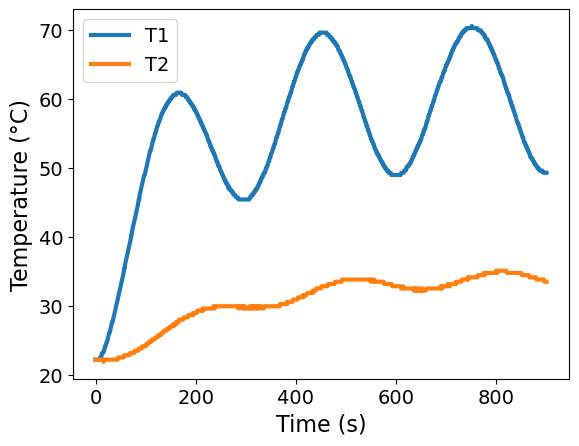

In [3]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

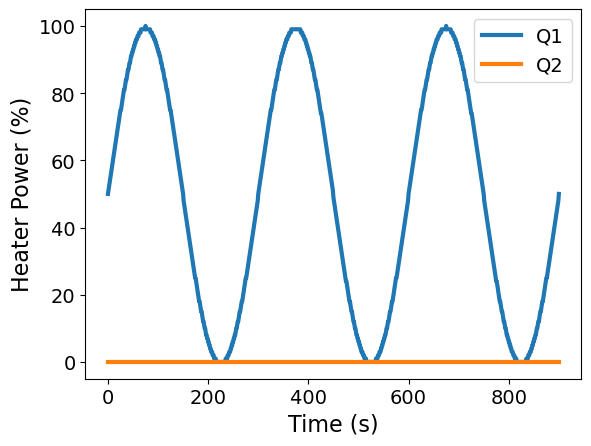

In [4]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

And then we will store the data in an instance of our `TC_Lab_data` dataclass.

In [5]:
# Here, we will induce a step size of 6 seconds, as to not give too many 
# degrees of freedom for experimental design.
skip =6

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Calculate FIM at initial point (sine test)

We will start computing the FIM of the sine test experiment.

In [6]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# Copied from previous notebook
theta_values = {
    'Ua': 0.041007,
    'Ub': 0.014152,
    'inv_CpH': 0.170600,
    'inv_CpS': 4.545456,
}

In [7]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1e-3,
                                 scale_nominal_param_value=True, 
                                 tee=True,)

We will define a prior FIM from the ParmEst exercise and look at its eigendecomposition


In [8]:
import numpy as np

cov = np.array([
    [2.431122e-10, -1.411022e-09, 4.013878e-09, -2.421788e-11],
    [-1.411022e-09, 1.159466e-06, 5.106751e-07, -3.727706e-04],
    [4.013878e-09, 5.106751e-07, 4.906845e-07, -1.975614e-04],
    [-2.421788e-11, -3.727706e-04, -1.975614e-04, 1.249945e-01],
])

FIM_raw = np.linalg.inv(cov)

theta_nom = np.array([
    theta_values['Ua'],
    theta_values['Ub'],
    theta_values['inv_CpH'],
    theta_values['inv_CpS'],
])

FIM_raw = np.linalg.inv(cov)
scale_constant_value = 1e-3
D = np.diag(theta_nom)
FIM = scale_constant_value**2* (D @ FIM_raw @ D)


eigvals, eigvecs = np.linalg.eigh(FIM)
eigvals = eigvals[::-1]
eigvecs = eigvecs[:, ::-1]

print("======Results Summary======")
print("Four design criteria log10() value:")
print("A-optimality:", np.log10(np.trace(np.linalg.pinv(FIM))))
print("D-optimality:", np.log10(np.linalg.det(FIM)))
print("E-optimality:", np.log10(np.min(eigvals)))
print("Modified E-optimality:", np.log10(np.max(eigvals) / np.min(eigvals)))
print("\nFIM:\n", FIM)
print("\neigenvalues:\n", eigvals)
print("\neigenvectors:\n", eigvecs)

======Results Summary======
Four design criteria log10() value:
A-optimality: 4.073937640114934
D-optimality: -5.3188509751520705
E-optimality: -4.0691188899680535
Modified E-optimality: 5.148048351164772

FIM:
 [[11.73698232 -0.10890206 -1.67610102 -0.17489925]
 [-0.10890206  0.01617503  0.09599044  0.0195361 ]
 [-1.67610102  0.09599044  0.82914952  0.12686458]
 [-0.17489925  0.0195361   0.12686458  0.02422106]]

eigenvalues:
 [1.19930449e+01 6.05651023e-01 7.74668681e-03 8.52866606e-05]

eigenvectors:
 [[-9.88698183e-01  1.49245090e-01 -1.42051210e-02  1.43521523e-04]
 [ 1.02079500e-02  1.35147335e-01  7.02366605e-01 -6.98793352e-01]
 [ 1.48709105e-01  9.64634059e-01 -2.15807267e-01 -2.81772577e-02]
 [ 1.60406668e-02  1.70124170e-01  6.78164133e-01  7.14768405e-01]]


## Optimize next experiment (D-optimality)

We are now ready to solve the optimization problem! Notice we create a new `DesignOfExperiments` object and specify the `prior_FIM` as result for the sine wave test. Thus we are decided what is the next best experiment to conduct. We already completed to sine test; we should use the data!

In [9]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=scale_constant_value,
                                 scale_nominal_param_value=True,
                                 objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
                                 prior_FIM=FIM,  # We use the prior information from the existing experiment!,,,,,,,,,,,,,,,,,,,,,,,
                                 tee=True,)


TC_Lab_DoE_D.run_doe()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

Now let's visualize the optimal experiment.

In [10]:
import numpy as np

eigvals = np.linalg.eigvals(TC_Lab_DoE_D.results["FIM"])
print(eigvals)
print("min eigenvalue:", np.min(eigvals))
print("condition number:", np.linalg.cond(TC_Lab_DoE_D.results["FIM"]))


[ 5526.8189323   9940.97779237 14434.41989802 18631.78666835]
min eigenvalue: 5526.818932300517
condition number: 3.3711592322051103


Now let's visualize the optimal experiment.

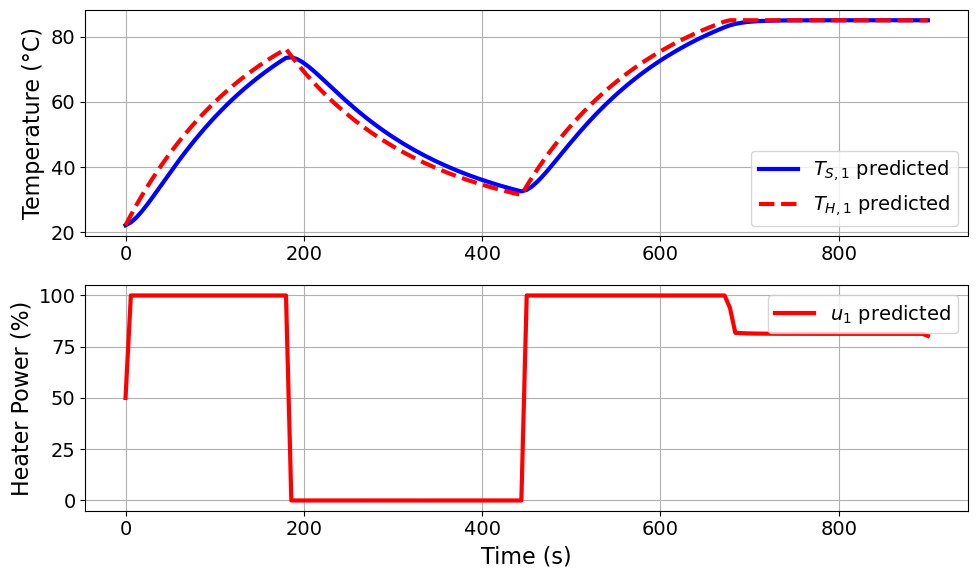

Model parameters:
Ua = 0.0414 Watts/degC
Ub = 0.0142 Watts/degC
CpH = 5.8617 Joules/degC
CpS = 0.22 Joules/degC
 


In [11]:
dopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_D.model.fd_scenario_blocks[0])

Fascinating. The D-optimal experiment is close to a square wave that fluctuates between maximum power and off. The square wave transitions from full power to off when the predicted sensor temperature reaches ~85 °C. Likewise, the heater turns back on when the sensor cools to ~60 °C. Then the following cycle allows the sensor to return to 40 °C. This experiment captures two cooling cycles and almost three full heating events.

Finally, let's analyze the predicted FIM of the new optimized experiment plus the existing sine wave experiment.

In [12]:
results_summary(TC_Lab_DoE_D.results['FIM'])

======Results Summary======
Four design criteria log10() value:
A-optimality: 4.686046115249025
D-optimality: 16.16955817795046
E-optimality: 3.7424752366116545
Modified E-optimality: 0.5277792663254229

FIM:
 [[np.float64(9305.152183920698), np.float64(-2785.9753392006537), np.float64(1033.8456326519683), np.float64(833.8971630485461)], [np.float64(-2785.9753392006537), np.float64(14039.145049739012), np.float64(1054.8488895220269), np.float64(3151.578398932437)], [np.float64(1033.8456326519683), np.float64(1054.8488895220269), np.float64(10189.550512545975), np.float64(-3950.164390516454)], [np.float64(833.8971630485461), np.float64(3151.578398932437), np.float64(-3950.164390516454), np.float64(15000.15554483905)]]

eigenvalues:
 [ 5526.8189323   9940.97779237 14434.41989802 18631.78666835]

eigenvectors:
 [[ 0.5573405   0.7351248  -0.36502545 -0.1253775 ]
 [ 0.41269167  0.13772275  0.72328794  0.53625794]
 [-0.57953925  0.60755027  0.44543204 -0.31081703]
 [-0.42800866  0.26740727 -

Success. The FIM of the new optimized experiment and the existing sine wave experiment is not rank deficient! We see from the eigendecomposition we still have the least information about parameter $C_p^S$. However, these results suggest we can uniquely estimate all four parameters using just two experiments.

## Optimize next experiment (A-optimality)

Next, we will consider A-optimality.

In [13]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)
print(FIM)
# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=scale_constant_value,
                                 scale_nominal_param_value=True,
                                 objective_option="trace",  # Now we specify a type of objective, A-opt = "trace"
                                 prior_FIM=FIM,  # We use the prior information from the same existing experiment as in the D-optimal case!
                                 tee=True,)

TC_Lab_DoE_A.run_doe()

[[11.73698232 -0.10890206 -1.67610102 -0.17489925]
 [-0.10890206  0.01617503  0.09599044  0.0195361 ]
 [-1.67610102  0.09599044  0.82914952  0.12686458]
 [-0.17489925  0.0195361   0.12686458  0.02422106]]
Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computa

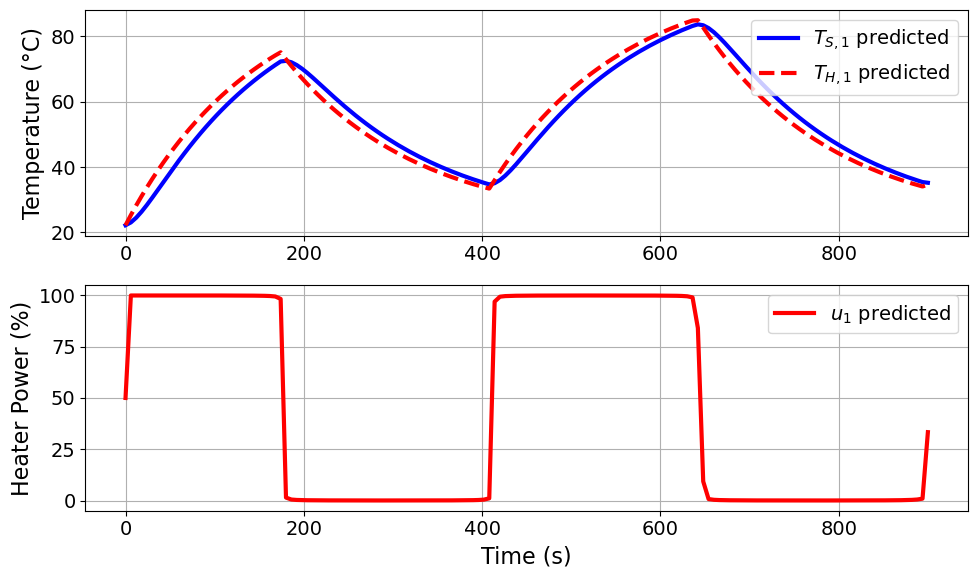

Model parameters:
Ua = 0.0414 Watts/degC
Ub = 0.0142 Watts/degC
CpH = 5.8617 Joules/degC
CpS = 0.22 Joules/degC
 


In [14]:
dopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_A.model.fd_scenario_blocks[0])

Interestingly, we obtain a different optimal experiment. The square-tooth-like structure appears to resemble the first cycle of the D-optimal experiment; however, the predicted temperature trajectory operates over a higher temperature range than in the corresponding D-optimal design. This suggests that the A-optimal criterion favors operation at higher temperatures, rather than simply reproducing the D-optimal input profile.


In [15]:
results_summary(TC_Lab_DoE_A.results['FIM'])

======Results Summary======
Four design criteria log10() value:
A-optimality: 4.684178561922553
D-optimality: 16.15911509759765
E-optimality: 3.7692778190124363
Modified E-optimality: 0.5225753536851632

FIM:
 [[np.float64(5883.892409882928), np.float64(-14.57816980114281), np.float64(36.11330452415783), np.float64(197.49846408812897)], [np.float64(-14.57816980114281), np.float64(19505.647356347043), np.float64(373.0165437875053), np.float64(-607.689022977289)], [np.float64(36.11330452415783), np.float64(373.0165437875053), np.float64(9129.892465259483), np.float64(158.48643216198715)], [np.float64(197.49846408812897), np.float64(-607.689022977289), np.float64(158.48643216198715), np.float64(13806.313212930787)]]

eigenvalues:
 [ 5878.65290826 19581.82534615 13755.47227402  9109.79491598]

eigenvectors:
 [[-9.99645907e-01 -2.46432888e-03 -2.49332460e-02 -8.96216564e-03]
 [-2.40280295e-04  9.94023346e-01 -1.02305444e-01  3.80936465e-02]
 [ 9.92778648e-03  3.38938471e-02 -4.24862343e-02 

## Sensitivity Analysis

The eigendecomposition of the FIM above shows we have the least information (and thus greatest uncertainty) about parameter $C_p^S$. In fact, notice that $C_p^S$ goes to its bound in our earlier [parameter estimation](./parmest.ipynb) analysis.

This uncertainty motivates performing a sensivitiy analysis of the optimal experiment design to perturbations in $C_p^S$. The code below focuses on A-optimality because it is computational less expensive, but and can easily adapted to D-optimality by changing the `objective_option`.

In [16]:
import numpy as np

CpS_values = np.array([ 0.01, 0.05, 0.1, 0.5, 1.0])
a_opt = np.zeros((len(CpS_values)))
u_solutions = np.zeros((len(CpS_values), len(tc_data.time)))
Ts_solutions = np.zeros((len(CpS_values), len(tc_data.time)))

for i, v in enumerate(CpS_values):

    print("\n********************\nCpS = ", v, " J/°C")

    theta_values_new = theta_values.copy()
    theta_values_new['inv_CpS'] = 1 / v

    # Create experiment object for design of experiments
    doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values_new, number_of_states=number_tclab_states)
    
    # Create the design of experiments object using our experiment instance from above
    TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                     step=1e-2,
                                     scale_constant_value=scale_constant_value,
                                     scale_nominal_param_value=True, 
                                     tee=False,)

    FIM_new = TC_Lab_DoE.compute_FIM(method='sequential')

    # Create a new DoE object
    TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                     step=1e-2,
                                     scale_constant_value=scale_constant_value,
                                     scale_nominal_param_value=True,
                                     objective_option="trace",  # We specify a type of objective, A-opt = "trace"
                                     prior_FIM=FIM,  # We use the prior information from the original experiment
                                     tee=False,)
    
    TC_Lab_DoE.run_doe()

    
    pyomo_results = extract_results(TC_Lab_DoE.model.fd_scenario_blocks[0])

    results_summary(TC_Lab_DoE.results['FIM'])

    a_opt[i] = np.log10(np.trace(TC_Lab_DoE.results['FIM']))
    u_solutions[i, :] = pyomo_results.u1
    Ts_solutions[i, :] = pyomo_results.TS1_data

    print("********************\n")


********************
CpS =  0.01  J/°C
======Results Summary======
Four design criteria log10() value:
A-optimality: 4.679954722607077
D-optimality: 16.24596744929052
E-optimality: 3.8839711720339736
Modified E-optimality: 0.3221083068478888

FIM:
 [[np.float64(10109.861712449348), np.float64(1931.2852242584777), np.float64(545.5134978300049), np.float64(615.290956005794)], [np.float64(1931.2852242584777), np.float64(13401.667492544506), np.float64(-2082.837895757661), np.float64(-725.2354240698328)], [np.float64(545.5134978300049), np.float64(-2082.837895757661), np.float64(13458.89503367378), np.float64(-2527.33182705121)], [np.float64(615.290956005794), np.float64(-725.2354240698328), np.float64(-2527.33182705121), np.float64(10887.595293281043)]]

eigenvalues:
 [ 7655.4578918  10523.87723075 13606.33079698 16072.35361243]

eigenvectors:
 [[-0.5681188   0.72892758 -0.3474846   0.15861924]
 [ 0.42133841 -0.1205951  -0.66659524  0.60297723]
 [ 0.44412544  0.29898046 -0.43061519 -0.72

Now let's visualize how the *A-optimality objective* changes as a function of $C_p^S$.

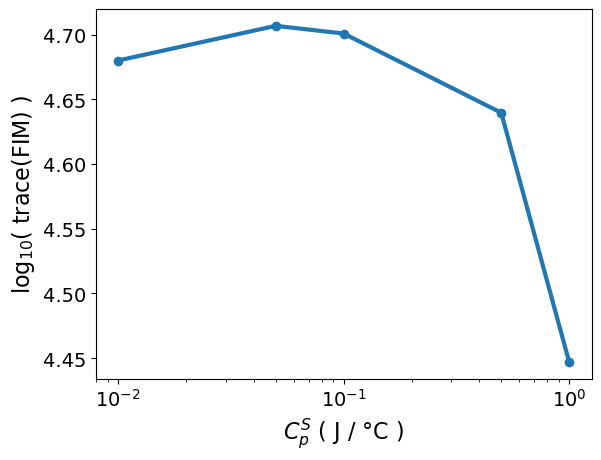

In [17]:
import matplotlib.pyplot as plt

plt.semilogx(CpS_values, a_opt, marker='o')
plt.xlabel('$C_p^S$ ( J / °C )')
plt.ylabel('log$_{10}$( trace(FIM) )')
plt.show()

We observe that the A-optimality objective decreases as the assumed value of $C_p^S$ increases over the tested range $C_p^S \in \{0.5,\,1.0,\,1.5,\,2.0\}$ J/$^\circ$C. Since A-optimality is based on $\mathrm{trace}(F^{-1})$, smaller values correspond to lower average parameter uncertainty. Thus, within this tested range, larger values of $C_p^S$ lead to slightly better A-optimality values. At the same time, the numerical differences remain small, so the objective is still only weakly sensitive to the assumed value of $C_p^S$.
What about the optimal solution?


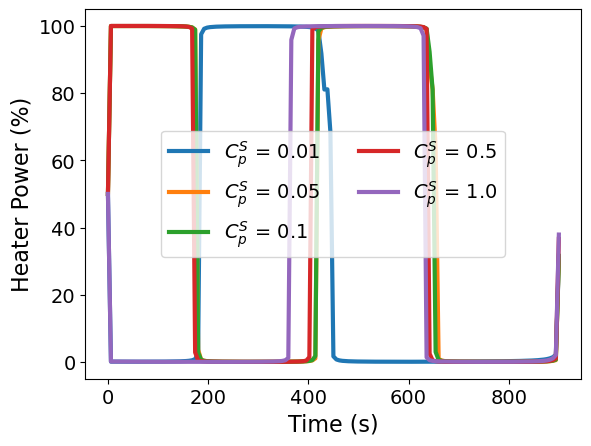

In [18]:
for i, v in enumerate(CpS_values):
    plt.plot(tc_data.time, u_solutions[i, :], label=f'$C_p^S$ = {v}')
plt.legend(ncol=2, loc='best')
plt.xlabel('Time (s)')
plt.ylabel('Heater Power (%)')
plt.show()

The corresponding optimal heater profiles are all smooth and qualitatively similar across the tested values of $C_p^S$. As $C_p^S$ increases, the heater profile becomes slightly flatter and less aggressive at the initial time step, but the overall shape remains consistent. This suggests that, over this range, the A-optimal design is much more stable than in the smaller-$C_p^S$ cases considered earlier.

Let's also look at the optimal sensor temperature profile:

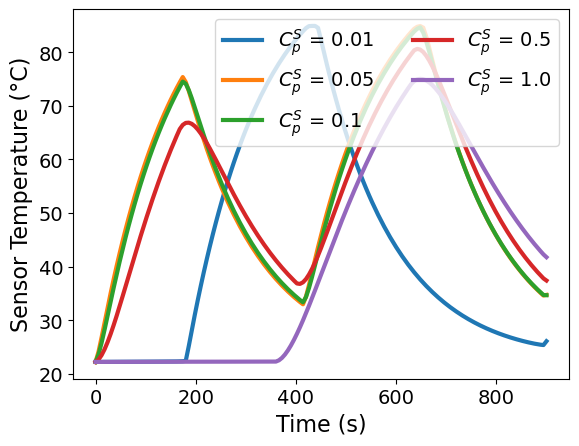

In [19]:
for i, v in enumerate(CpS_values):
    plt.plot(tc_data.time, Ts_solutions[i, :], label=f'$C_p^S$ = {v}')
plt.legend(ncol=2, loc='best')
plt.xlabel('Time (s)')
plt.ylabel('Sensor Temperature (°C)')
plt.show()

The results above show that the A-optimal design is relatively stable over the tested range of $C_p^S$. However, A-optimality is still an average measure of uncertainty. If we instead want to focus more directly on the weakest-informed directions in parameter space, we need different criteria.


Up to this point, we have explored D-optimality and A-optimality using algebraic formulations inside the Pyomo model. This raises an important implementation question: how do we represent different design criteria within an equation-oriented optimization problem?

For some objectives, such as determinant-based criteria, convenient algebraic reformulations exist. For other criteria, especially those involving eigenvalues, the formulation is much more difficult. To understand this distinction, we first review the Cholesky-based approach used for determinant-style objectives, and then motivate the GreyBox formulation used for more general criteria such as E-optimality and ME-optimality.


Recall that the Fisher information matrix depends on the experiment design $u$ and is given by

$$
\mathbf{M}(u) = \mathbf{Q}(u)^\top \Sigma_y^{-1} \mathbf{Q}(u) + \mathbf{M}_0,
$$

where $\mathbf{Q}(u)$ is the sensitivity matrix, $\Sigma_y$ is the measurement covariance matrix, and $\mathbf{M}_0$ is the prior Fisher information matrix from earlier experiments.

<!-- The sensitivity matrix $\mathbf{Q}(u)$ collects the sensitivities of the measured outputs with respect to the unknown parameters. Its rows correspond to measurement locations, and its columns correspond to parameters:

$$
\mathbf{Q}(u) =
\begin{bmatrix}
q_{1,1} & q_{1,2} & \cdots & q_{1,p} \\
q_{2,1} & q_{2,2} & \cdots & q_{2,p} \\
\vdots  & \vdots  & \ddots & \vdots \\
q_{N_{\mathrm{meas}},1} & q_{N_{\mathrm{meas}},2} & \cdots & q_{N_{\mathrm{meas}},p}
\end{bmatrix}.
$$ -->

Here, $q_{i,j}$ denotes the sensitivity of the $i$th measurement with respect to the $j$th parameter.


When $\mathbf{M}(u) + \mathbf{M}_0$ is symmetric positive definite, it admits a Cholesky factorization,

$$
\mathbf{M}(u) + \mathbf{M}_0 = \mathbf{L}\mathbf{L}^\top,
$$

where $\mathbf{L}$ is lower triangular.

For D-optimality, we wish to maximize a determinant-based scalarization:

$$
\max_u \ \psi\!\left(\mathbf{M}(u) + \mathbf{M}_0\right)
\qquad \text{with} \qquad
\psi(\cdot) = \log_{10}\det(\cdot).
$$

Using the Cholesky factorization, we can write

$$
\det\!\left(\mathbf{M}(u) + \mathbf{M}_0\right)
=
\det(\mathbf{L})^2
=
\left(\prod_i L_{ii}\right)^2.
$$

This makes determinant-based criteria attractive to represent using algebraic constraints inside the optimization model.

This algebraic strategy works well for determinant-based objectives, but it does not extend naturally to all choices of $\psi(\cdot)$.

In particular:

- **E-optimality** seeks to maximize the smallest eigenvalue,

$$
\max_u \ \psi\!\left(\mathbf{M}(u) + \mathbf{M}_0\right)
\qquad \text{with} \qquad
\psi(\cdot) = \lambda_{\min}(\cdot),
$$

- **ME-optimality** seeks to improve the conditioning of the Fisher information matrix by minimizing the ratio of the largest to the smallest eigenvalue,

$$
\min_u \ \psi\!\left(\mathbf{M}(u) + \mathbf{M}_0\right)
\qquad \text{with} \qquad
\psi(\cdot) = \frac{\lambda_{\max}(\cdot)}{\lambda_{\min}(\cdot)}.
$$

These criteria depend directly on the eigenvalues of the Fisher information matrix. Unlike the determinant, eigenvalues are not easy to represent compactly as explicit algebraic constraints in a general nonlinear optimization model. As a result, a Cholesky-based algebraic reformulation is no longer the most natural approach for these criteria.



## Greybox Formulation
To handle these more general design criteria, we provide a GreyBox module within Pyomo.DoE.

In the GreyBox formulation, the Pyomo model computes the Fisher information matrix, while the scalar design criterion is evaluated externally as

$$
\psi = \psi\!\left(\mathbf{M}(u)+ \mathbf{M}_0\right).
$$

Thus:

- the Pyomo model computes $\mathbf{Q}(u)$ and $\mathbf{M}(u) + \mathbf{M}_0$,
- the GreyBox block takes $\mathbf{M}(u)$ as input,
- the GreyBox block returns the scalar objective value $\psi(\mathbf{M}(u)+ \mathbf{M}_0$).

In addition, the GreyBox callback provides derivative information such as

$$
\frac{\partial \psi}{\partial \mathbf{M}}
\qquad \text{and optionally} \qquad
\frac{\partial^2 \psi}{\partial \mathbf{M}^2},
$$

which allows a gradient-based optimizer such as IPOPT to solve the resulting problem efficiently.

The difficult part is not constructing $\mathbf{M}(u)$ — Pyomo already does that. The difficult part is evaluating quantities such as matrix inverses, smallest eigenvalues, and condition numbers. The GreyBox formulation handles those operations externally, while still supplying derivative information back to the optimizer.


## Optimize next experiment (E-optimality and ME-optimality)

We now turn to two eigenvalue-based criteria that are implemented through the GreyBox objective formulation. We consider E-optimal design first. 

Recall that the minimum eigenvalue of the FIM is along $C_{pS}$, E-optimality returns experiment design that maximizes the information along this direction.



In [20]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)

# Create the design of experiments object
TC_Lab_DoE_E = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=scale_constant_value,
    scale_nominal_param_value=True,
    objective_option="minimum_eigenvalue",  # E-optimality
    prior_FIM=FIM,
    tee=True,
)

# Use the GreyBox objective implementation
TC_Lab_DoE_E.use_grey_box = True

# Solve
TC_Lab_DoE_E.run_doe()


Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [21]:
print("=== E-optimal design summary ===")


results_summary(TC_Lab_DoE_E.results["FIM"])


=== E-optimal design summary ===
======Results Summary======
Four design criteria log10() value:
A-optimality: 2.9123266406670667
D-optimality: -0.6289730306058129
E-optimality: -1.7484113547877869
Modified E-optimality: 4.660238473681974

FIM:
 [[np.float64(816.2561990033358), np.float64(0.3163353183263539), np.float64(0.8500973072601729), np.float64(0.3704883554726691)], [np.float64(0.3163353183263539), np.float64(0.029851349466126494), np.float64(0.10066381991388186), np.float64(0.0179327953092329)], [np.float64(0.8500973072601729), np.float64(0.10066381991388186), np.float64(0.8660662012456437), np.float64(0.15061737740947237)], [np.float64(0.3704883554726691), np.float64(0.0179327953092329), np.float64(0.15061737740947237), np.float64(0.04465206861755806)]]

eigenvalues:
 [8.16257376e+02 9.03696416e-01 1.78479625e-02 1.78479625e-02]

eigenvectors:
 [[-9.99999278e-01  1.14341711e-03  3.34805911e-04  1.54163590e-04]
 [-3.87696060e-04 -1.15808727e-01 -9.27613332e-01  3.59366228e-01]


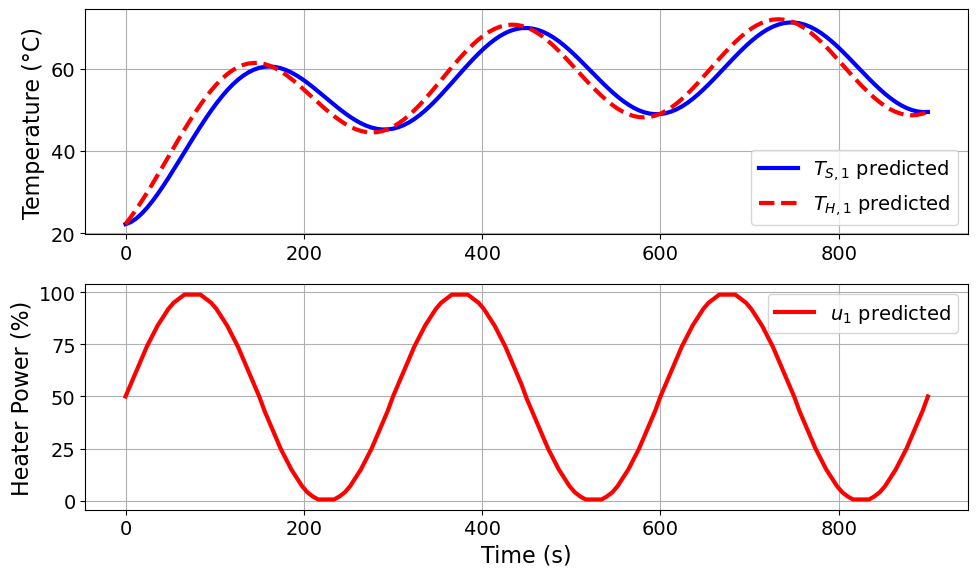

Model parameters:
Ua = 0.0414 Watts/degC
Ub = 0.0142 Watts/degC
CpH = 5.8617 Joules/degC
CpS = 0.22 Joules/degC
 


In [22]:
Eopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_E.model.fd_scenario_blocks[0])

The results indicate that experiment design that provides the maximum information along the minimum eigenvalue, thereby reducing the uncertainty in $C_{pS}$ favors operation of the system at a lower temperature than D- and A- optimality. 

E-optimality improves the weakest identifiable direction by increasing the smallest eigenvalue. However, the resulting FIM still shows a large gap between the largest and smallest eigenvalues, meaning the experiment provides much more information in some directions than others. Therefore, we consider modified ME-optimality, which aims to reduce this gap and produce a more balanced distribution of information across parameters.

In [23]:

# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)

# Create the design of experiments object
TC_Lab_DoE_ME = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=scale_constant_value,
    scale_nominal_param_value=True,
    objective_option="condition_number",  # ME-optimality
    prior_FIM=FIM,
    tee=True,
)

# Use the GreyBox objective implementation
TC_Lab_DoE_ME.use_grey_box = True

# Solve
TC_Lab_DoE_ME.run_doe()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [27]:
print("=== ME-optimal design summary ===")


results_summary(TC_Lab_DoE_ME.results["FIM"])

=== ME-optimal design summary ===
======Results Summary======
Four design criteria log10() value:
A-optimality: 1.4301343868482228
D-optimality: 0.5626628342085754
E-optimality: -2.2487363415123314
Modified E-optimality: 3.3304666757897357

FIM:
 [[np.float64(12.050080205363054), np.float64(0.31636781499773736), np.float64(0.10928896159193666), np.float64(-0.13748218588732408)], [np.float64(0.31636781499773736), np.float64(3.2298185696143853), np.float64(2.0122531367718217), np.float64(2.8534914789419585)], [np.float64(0.10928896159193666), np.float64(2.0122531367718217), np.float64(7.8922013728297395), np.float64(-1.0437328812532016)], [np.float64(-0.13748218588732408), np.float64(2.8534914789419585), np.float64(-1.0437328812532016), np.float64(3.751577788865755)]]

eigenvalues:
 [1.20706410e+01 5.63979942e-03 8.62746549e+00 6.21993163e+00]

eigenvectors:
 [[ 0.99775683  0.02387595 -0.06181885 -0.00946997]
 [ 0.04456026 -0.72794192  0.34779554  0.58919708]
 [ 0.04940535  0.26881804  0

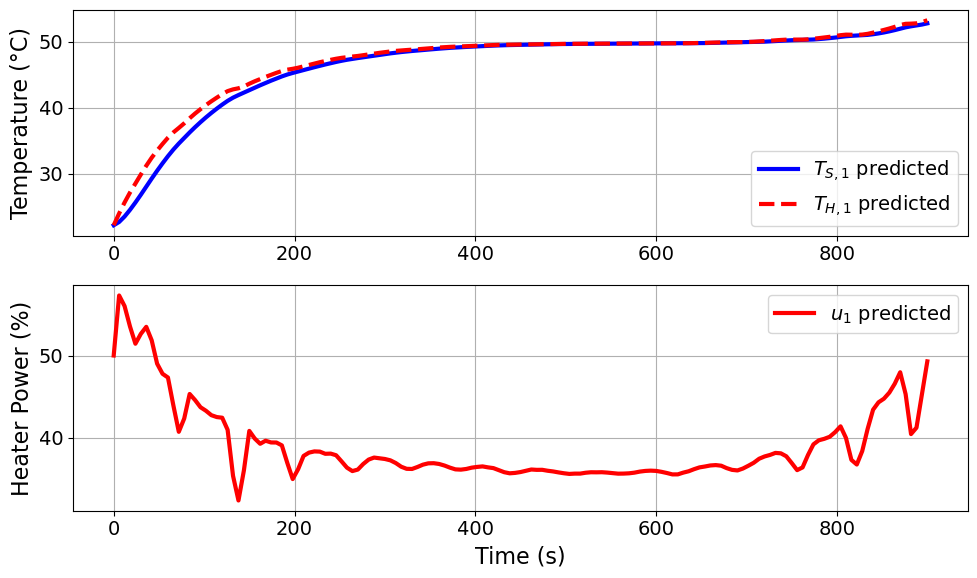

Model parameters:
Ua = 0.0414 Watts/degC
Ub = 0.0142 Watts/degC
CpH = 5.8617 Joules/degC
CpS = 0.22 Joules/degC
 


In [25]:
MEopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_ME.model.fd_scenario_blocks[0])

The ME-optimal design is also qualitatively similar to the A- and E-optimal designs, again using repeated heater pulses to generate informative transients. In this case, the visible experiment trajectory alone does not clearly distinguish the criterion. Instead, the main purpose of ME-optimality is reflected in the Fisher information matrix itself: it seeks to improve conditioning by reducing the disparity between the largest and smallest eigenvalues, thereby promoting a more balanced distribution of information across parameter directions. Let us compare the objective values across all optimalities


In [26]:
import numpy as np
import pandas as pd

def fim_metrics(FIM):
    eigvals = np.linalg.eigvalsh(np.array(FIM, dtype=float))
    return {
        "A-opt": np.log10(np.trace(np.linalg.pinv(FIM))),
        "D-opt": np.log10(np.linalg.det(FIM)),
        "E-opt": np.log10(np.min(eigvals)),
        "ME-opt": np.log10(np.max(eigvals) / np.min(eigvals)),
    }

comparison_df = pd.DataFrame(
    {
        "D-opt design": fim_metrics(TC_Lab_DoE_D.results["FIM"]),
        "A-opt design": fim_metrics(TC_Lab_DoE_A.results["FIM"]),
        "E-opt design": fim_metrics(TC_Lab_DoE_E.results["FIM"]),
        "ME-opt design": fim_metrics(TC_Lab_DoE_ME.results["FIM"]),
    }
).T

comparison_df = comparison_df[["A-opt", "D-opt", "E-opt", "ME-opt"]]
comparison_df = comparison_df.round(6)

print("=== Objective comparison table ===")
display(comparison_df)


=== Objective comparison table ===


,A-opt,D-opt,E-opt,ME-opt
D-opt design,-3.393103,16.169558,3.742475,0.527779
A-opt design,-3.394000,16.159115,3.769278,0.522575
E-opt design,2.053714,-0.628973,-1.748411,4.660238
ME-opt design,2.249616,0.562663,-2.248736,3.330467


The four objectives are mathematically distinct, but for the TC Lab example they produce only modest differences in the resulting information metrics and very similar pulsed experiment designs. This suggests that the same general experiment family is informative across all four criteria, even though each objective emphasizes a different property of the Fisher information matrix.
